# HHRI–Quobly `qpe-toolbox`: Symmetry-Resolved QPE Resource Scaling Near Quantum Criticality

## Research focus

The `qpe-toolbox`, jointly developed by the Hon Hai Research Institute Quantum Computing Research Center and Quobly, is used here as the central computational framework for studying how Quantum Phase Estimation resources change near many-body criticality.

The core problem is spectral conditioning. In a finite system with exact symmetries, the smallest global level spacing can be much smaller than the spectral separation actually accessible from the prepared state. QPE resources should therefore be tied to the **accessible spectral support** rather than to the minimum eigenvalue spacing without regard to symmetry or state overlap.

For the transverse-field Ising chain,

$$
H_{\mathrm{TFIM}}
=
-J\sum_{i=0}^{L-2} Z_iZ_{i+1}
-g\sum_{i=0}^{L-1}X_i,
$$

we compare

$$
\Delta_{\mathrm{global}}=E_1-E_0
$$

with the same-parity gap

$$
\Delta_{\mathrm{sym}}
=
\min_{\substack{n>0\\p_n=p_0}}(E_n-E_0).
$$

The analysis then propagates these spectral scales through the toolbox QPE workflow: MPS preparation, exact/Trotterised time evolution, textbook QPE, Robust Phase Estimation, and resource-only gate construction.

## 1. Install the current toolbox

The installation is upgraded explicitly so that Colab uses the current PyPI release.

The cell immediately after installation checks the exact methods used later in the file. In particular, this version **does not call `Hamiltonian.to_sparse_matrix()`**. Exact diagonalisation uses a compatibility converter built from the documented `Hamiltonian.terms` representation.

In [1]:
!pip -q install -U qpe-toolbox quimb scipy pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.9/952.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 534.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.

## 2. Import and verify the live API

In [2]:
import importlib.metadata as metadata
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as sla
import scipy.linalg as la
import quimb.tensor as qtn

import qpe_toolbox.estimation as qpe
from qpe_toolbox import EXACT
from qpe_toolbox.hamiltonian import Hamiltonian
from qpe_toolbox.circuit.initialization import make_circ
from qpe_toolbox.circuit import count_gates_by_qb

print("qpe-toolbox:", metadata.version("qpe-toolbox"))
print("quimb:", metadata.version("quimb"))

# These are documented methods used throughout the analysis.
required_hamiltonian_methods = [
    "to_mpo",
    "get_U_exact",
    "get_trotter_step",
]

for method in required_hamiltonian_methods:
    assert hasattr(Hamiltonian, method), (
        f"Installed qpe-toolbox lacks documented Hamiltonian.{method}"
    )

required_qpe_functions = [
    "qpe_energy",
    "qpe_sample",
    "set_search_window",
    "robust_phase_estimation",
]

for name in required_qpe_functions:
    assert hasattr(qpe, name), (
        f"Installed qpe-toolbox lacks estimation.{name}"
    )

print("Required live API verified.")
print()
print("qpe_energy signature:")
print(inspect.signature(qpe.qpe_energy))
print()
print("qpe_sample signature:")
print(inspect.signature(qpe.qpe_sample))

qpe-toolbox: 1.1.0
quimb: 1.15.0
Required live API verified.

qpe_energy signature:
(hamiltonian, initial_circ, n_steps, E_target, size_interval, *, trotter_order=1, write_gates=False, optimize='auto-hq', verbosity=0)

qpe_sample signature:
(hamiltonian, initial_circ, evolution_time, dt, global_phase, *, trotter_order=1, write_gates=False, rehearse=False, run_simulation=True, optimize='auto-hq', verbosity=0)


### Circuit compatibility note

The current `qpe_toolbox.circuit.gate_count.count_gates()` implementation documents `CircuitMPS` support but its runtime type check accepts only `qtn.Circuit` or a gate list. This notebook therefore uses the official `make_circ(...)` factory for all QPE execution paths.

### Search-window API compatibility

`set_search_window()` has changed return arity across package revisions. Some Colab installations return four values,

```text
(E_const, E_max, evolution_time, global_phase)
```

whereas the current online API documentation lists three,

```text
(E_max, evolution_time, global_phase).
```

The analysis therefore uses `search_window_compat()` everywhere. The wrapper resolves both forms and exposes a named dictionary, eliminating positional unpacking from the rest of the code.

In [3]:

def search_window_compat(hamiltonian, E_target, size_interval):
    """
    Version-compatible wrapper around qpe.set_search_window().

    qpe-toolbox releases have exposed two return signatures:

      newer documentation:
          (E_max, evolution_time, global_phase)

      older/current PyPI builds encountered in Colab:
          (E_const, E_max, evolution_time, global_phase)

    Only E_max, evolution_time and global_phase are required downstream.
    """
    values = qpe.set_search_window(
        hamiltonian,
        E_target,
        size_interval,
    )

    if not isinstance(values, (tuple, list)):
        raise TypeError(
            "set_search_window returned an unsupported object: "
            f"{type(values)}"
        )

    if len(values) == 3:
        E_max, evolution_time, global_phase = values
        E_const = float(getattr(hamiltonian, "e_const", 0.0))

    elif len(values) == 4:
        E_const, E_max, evolution_time, global_phase = values

    else:
        raise RuntimeError(
            "Unsupported set_search_window return signature: "
            f"{len(values)} values"
        )

    return {
        "E_const": float(E_const),
        "E_max": float(E_max),
        "evolution_time": float(evolution_time),
        "global_phase": float(global_phase),
        "raw": values,
    }


# Verify the installed version immediately.
_test_H = tfim_hamiltonian(4, 1.0) if "tfim_hamiltonian" in globals() else None

print("search_window_compat defined.")


search_window_compat defined.


## 3. Toolbox-native Hamiltonian construction

`Hamiltonian` stores a model as Pauli terms

$$
(c,\;P,\;[i_1,\ldots,i_k]).
$$

The helper below constructs TFIM and XXZ models directly as toolbox Hamiltonians.

In [4]:
def tfim_hamiltonian(L, g, J=1.0):
    """Open-boundary transverse-field Ising model."""
    terms = []

    for i in range(L - 1):
        terms.append((-J, "zz", [i, i + 1]))

    for i in range(L):
        terms.append((-g, "x", [i]))

    return Hamiltonian(terms, L)


def xxz_hamiltonian(L, delta, J=1.0):
    """Open-boundary spin-1/2 XXZ chain."""
    terms = []

    for i in range(L - 1):
        terms.extend(
            [
                (J / 4.0, "xx", [i, i + 1]),
                (J / 4.0, "yy", [i, i + 1]),
                (J * delta / 4.0, "zz", [i, i + 1]),
            ]
        )

    return Hamiltonian(terms, L)


H4 = tfim_hamiltonian(4, 1.0)

print("n_qubits =", H4.n_qubits)
print("number of Pauli terms =", len(H4.terms))

mpo4 = H4.to_mpo()

print("MPO sites =", mpo4.L)
print("MPO max bond =", mpo4.max_bond())

n_qubits = 4
number of Pauli terms = 7
MPO sites = 4
MPO max bond = 3


## 4. Compatibility-safe sparse conversion from `Hamiltonian.terms`

The current public toolbox does not require a sparse-matrix conversion method on `Hamiltonian`. For exact finite-size diagnostics, the converter below reads the toolbox Hamiltonian's own Pauli-term list and constructs a SciPy sparse operator.

This keeps `Hamiltonian` as the single source of the model definition while avoiding undocumented API calls.

In [5]:
PAULI = {
    "i": sp.csr_matrix(np.eye(2, dtype=complex)),
    "x": sp.csr_matrix(np.array([[0, 1], [1, 0]], dtype=complex)),
    "y": sp.csr_matrix(np.array([[0, -1j], [1j, 0]], dtype=complex)),
    "z": sp.csr_matrix(np.array([[1, 0], [0, -1]], dtype=complex)),
}


def sparse_kron_all(ops):
    out = ops[0]

    for op in ops[1:]:
        out = sp.kron(out, op, format="csr")

    return out


def toolbox_hamiltonian_to_sparse(ham):
    """
    Convert qpe-toolbox Hamiltonian.terms to a SciPy CSR matrix.

    This is intentionally implemented here rather than relying on an
    undocumented Hamiltonian matrix-conversion method.
    """
    L = ham.n_qubits
    dim = 2**L

    Hs = sp.csr_matrix((dim, dim), dtype=complex)

    for coeff, pauli_string, active_qubits in ham.terms:
        local_ops = [PAULI["i"] for _ in range(L)]

        for symbol, qubit in zip(pauli_string.lower(), active_qubits):
            local_ops[qubit] = PAULI[symbol]

        Hs = Hs + coeff * sparse_kron_all(local_ops)

    # Chemistry Hamiltonians may carry a constant energy shift.
    e_const = getattr(ham, "e_const", 0.0)

    if e_const:
        Hs = Hs + e_const * sp.identity(dim, format="csr", dtype=complex)

    return Hs


H4_sparse = toolbox_hamiltonian_to_sparse(H4)

print("sparse shape =", H4_sparse.shape)
print("Hermitian check =", np.max(np.abs((H4_sparse - H4_sparse.getH()).data)) if (H4_sparse - H4_sparse.getH()).nnz else 0.0)

sparse shape = (16, 16)
Hermitian check = 0.0


## 5. Symmetry operator and low-energy spectrum

In [6]:
def global_x_parity_sparse(L):
    return sparse_kron_all([PAULI["x"] for _ in range(L)])


def low_spectrum_toolbox(ham, k=8):
    Hs = toolbox_hamiltonian_to_sparse(ham)

    k_eff = min(k, Hs.shape[0] - 2)

    vals, vecs = sla.eigsh(
        Hs,
        k=k_eff,
        which="SA",
    )

    order = np.argsort(np.real(vals))

    return np.real(vals[order]), vecs[:, order]


def tfim_spectral_data(L, g, k=8):
    ham = tfim_hamiltonian(L, g)

    vals, vecs = low_spectrum_toolbox(ham, k=k)

    parity_op = global_x_parity_sparse(L)

    pexp = np.real(
        np.einsum(
            "ij,ij->j",
            np.conjugate(vecs),
            parity_op @ vecs,
        )
    )

    parity = np.where(pexp >= 0, 1, -1)
    p0 = parity[0]

    same_sector_energies = [
        vals[j]
        for j in range(1, len(vals))
        if parity[j] == p0
    ]

    return {
        "E0": vals[0],
        "E1": vals[1],
        "global_gap": vals[1] - vals[0],
        "symmetry_gap": same_sector_energies[0] - vals[0],
        "ground_parity": int(p0),
    }


print(tfim_spectral_data(4, 1.0))

{'E0': np.float64(-4.758770483143641), 'E1': np.float64(-4.0641777724759045), 'global_gap': np.float64(0.6945927106677363), 'symmetry_gap': np.float64(2.6945927106677248), 'ground_parity': 1}


## 6. Toolbox-defined TFIM finite-size sweep

In [7]:
L_VALUES = [4, 6, 8, 10]
G_VALUES = np.linspace(0.60, 1.40, 17)

rows = []

for L in L_VALUES:
    for g in G_VALUES:
        r = tfim_spectral_data(L, g)

        rows.append(
            {
                "L": L,
                "g": g,
                **r,
            }
        )

tfim_df = pd.DataFrame(rows)

tfim_df.head(12)

,L,g,E0,E1,global_gap,symmetry_gap,ground_parity
0,4,0.60,-3.631386,-3.458639,0.172747,1.795480,1
1,4,0.65,-3.747897,-3.526572,0.221325,1.868573,1
2,4,0.70,-3.872983,-3.597223,0.275760,1.955481,1
3,4,0.75,-4.005816,-3.670305,0.335511,2.054898,1
4,4,0.80,-4.145561,-3.745561,0.400000,2.165471,1
5,4,0.85,-4.291424,-3.822765,0.468659,2.285888,1
6,4,0.90,-4.442673,-3.901717,0.540956,2.414926,1
7,4,0.95,-4.598649,-3.982240,0.616409,2.551486,1
8,4,1.00,-4.758770,-4.064178,0.694593,2.694593,1
9,4,1.05,-4.922530,-4.147392,0.775138,2.843400,1


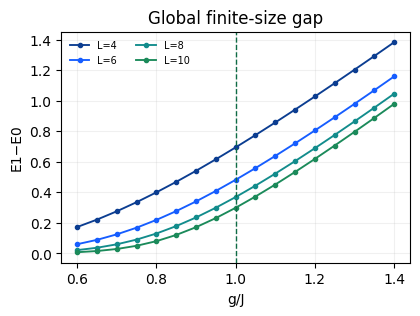

In [8]:
BLUE = "#165DFF"
BLUE2 = "#0B3D91"
GREEN = "#1B8A5A"
GREEN2 = "#0F6B45"
TEAL = "#128C8C"
FIGSIZE = (4.5, 3.0)

fig, ax = plt.subplots(figsize=FIGSIZE)

for L, color in zip(L_VALUES, [BLUE2, BLUE, TEAL, GREEN]):
    d = tfim_df[tfim_df.L == L]

    ax.plot(
        d.g,
        d.global_gap,
        marker="o",
        ms=3,
        lw=1.35,
        color=color,
        label=f"L={L}",
    )

ax.axvline(1.0, ls="--", lw=1, color=GREEN2)

ax.set(
    xlabel="g/J",
    ylabel="E1−E0",
    title="Global finite-size gap",
)

ax.legend(fontsize=7, frameon=False, ncol=2)
ax.grid(alpha=0.18)

plt.show()

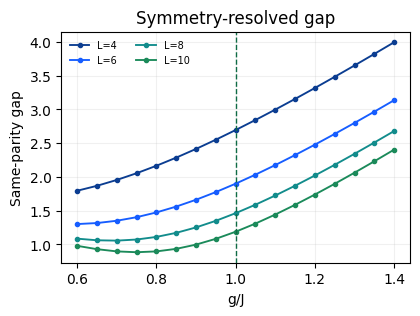

In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE)

for L, color in zip(L_VALUES, [BLUE2, BLUE, TEAL, GREEN]):
    d = tfim_df[tfim_df.L == L]

    ax.plot(
        d.g,
        d.symmetry_gap,
        marker="o",
        ms=3,
        lw=1.35,
        color=color,
        label=f"L={L}",
    )

ax.axvline(1.0, ls="--", lw=1, color=GREEN2)

ax.set(
    xlabel="g/J",
    ylabel="Same-parity gap",
    title="Symmetry-resolved gap",
)

ax.legend(fontsize=7, frameon=False, ncol=2)
ax.grid(alpha=0.18)

plt.show()

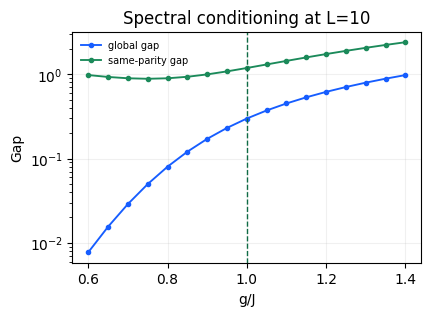

In [10]:
d = tfim_df[tfim_df.L == 10]

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.semilogy(
    d.g,
    d.global_gap,
    marker="o",
    ms=3,
    lw=1.35,
    color=BLUE,
    label="global gap",
)

ax.semilogy(
    d.g,
    d.symmetry_gap,
    marker="o",
    ms=3,
    lw=1.35,
    color=GREEN,
    label="same-parity gap",
)

ax.axvline(1.0, ls="--", lw=1, color=GREEN2)

ax.set(
    xlabel="g/J",
    ylabel="Gap",
    title="Spectral conditioning at L=10",
)

ax.legend(fontsize=7, frameon=False)
ax.grid(alpha=0.18)

plt.show()

## 7. DMRG through the toolbox MPO representation

For larger systems, the package's `to_mpo()` representation is passed directly to `quimb.tensor.DMRG2`. The resulting MPS is the natural QPE input state.

This section runs by default at a moderate system size; increase `L_DMRG` after the pipeline is verified.

In [11]:
L_DMRG = 12
g_DMRG = 1.0

H_dmrg = tfim_hamiltonian(L_DMRG, g_DMRG)
mpo_dmrg = H_dmrg.to_mpo()

dmrg = qtn.DMRG2(mpo_dmrg)

converged = dmrg.solve(
    max_sweeps=12,
    bond_dims=64,
    cutoffs=1e-10,
    tol=1e-8,
    verbosity=0,
)

psi0_dmrg = dmrg.state
E0_dmrg = float(np.real(dmrg.energy)) + float(getattr(H_dmrg, "e_const", 0.0))

print("converged =", converged)
print("DMRG E0 =", E0_dmrg)
print("MPS max bond =", psi0_dmrg.max_bond())

converged = True
DMRG E0 = -14.925971107513083
MPS max bond = 9


## 8. QPE circuit initialisation with `make_circ`

The current gate-count implementation accepts `qtn.Circuit` or a gate list. Therefore every QPE path in this file uses the toolbox factory `make_circ(n_phase_bits, psi_mps)`, which returns `qtn.Circuit`. The data state remains an MPS; only the circuit wrapper is changed.

In [12]:

def make_qpe_circuit(n_phase_bits, data_mps):
    """Return the toolbox-supported qtn.Circuit wrapper."""
    circ = make_circ(n_phase_bits, data_mps)
    assert isinstance(circ, qtn.Circuit), (
        f"Expected qtn.Circuit, received {type(circ)}"
    )
    return circ


def resource_only_qpe_circuit(n_phase_bits, n_data):
    """All-zero data MPS is sufficient when run_simulation=False."""
    data_mps = qtn.MPS_computational_state("0" * n_data)
    return make_qpe_circuit(n_phase_bits, data_mps)


_test_circ = resource_only_qpe_circuit(2, 3)
print("QPE circuit type:", type(_test_circ))
print("Total qubits:", _test_circ.N)


QPE circuit type: <class 'quimb.tensor.circuit.Circuit'>
Total qubits: 5


## 9. Textbook QPE with exact time evolution

In [13]:

ETA = 0.05
SEARCH_WINDOW = 2.0

def required_phase_bits(gap, eta=ETA, window=SEARCH_WINDOW):
    eps_each_energy = eta * gap / 2.0
    return int(np.ceil(np.log2(window / eps_each_energy)))

L_QPE = 4
g_QPE = 1.0

H_qpe = tfim_hamiltonian(L_QPE, g_QPE)
vals_qpe, vecs_qpe = low_spectrum_toolbox(H_qpe, k=4)

E0_exact = float(vals_qpe[0])
spec_qpe = tfim_spectral_data(L_QPE, g_QPE)
gap_qpe = float(spec_qpe["symmetry_gap"])

# Keep the full tensor-network simulation compact.
n_phase = min(required_phase_bits(gap_qpe), 5)

psi0_exact_mps = qtn.MatrixProductState.from_dense(
    vecs_qpe[:, 0],
    dims=[2] * L_QPE,
)

initial_circ = make_qpe_circuit(
    n_phase,
    psi0_exact_mps,
)

print("initial_circ type:", type(initial_circ))
assert isinstance(initial_circ, qtn.Circuit)

E_target = E0_exact + 0.25

traces_exact, E0_qpe = qpe.qpe_energy(
    H_qpe,
    initial_circ,
    EXACT,
    E_target,
    SEARCH_WINDOW,
    optimize="greedy",
    verbosity=0,
)

print("phase qubits =", n_phase)
print("exact E0 =", E0_exact)
print("QPE E0 =", E0_qpe)
print("absolute error =", abs(E0_qpe - E0_exact))
print("highest-probability phase probability =", traces_exact.get("prob"))


initial_circ type: <class 'quimb.tensor.circuit.Circuit'>
phase qubits = 5
exact E0 = -4.75877048314364
QPE E0 = -4.75877048314364
absolute error = 0.0
highest-probability phase probability = 1.0


## 10. Trotterised QPE within the analysis Hamiltonian

In [14]:

n_steps = 4
trotter_order = 2

# Fresh standard Circuit because qpe_energy mutates the circuit.
initial_circ_trot = make_qpe_circuit(
    n_phase,
    psi0_exact_mps,
)

assert isinstance(initial_circ_trot, qtn.Circuit)

traces_trot, E0_trot = qpe.qpe_energy(
    H_qpe,
    initial_circ_trot,
    n_steps,
    E_target,
    SEARCH_WINDOW,
    trotter_order=trotter_order,
    optimize="greedy",
    verbosity=0,
)

print("Trotter order =", trotter_order)
print("Trotter steps =", n_steps)
print("exact E0 =", E0_exact)
print("Trotter-QPE E0 =", E0_trot)
print("absolute error =", abs(E0_trot - E0_exact))
print("gate counts =", traces_trot.get("gates_count", {}))


Trotter order = 2
Trotter steps = 4
exact E0 = -4.75877048314364
Trotter-QPE E0 = -4.00877048314364
absolute error = 0.75
gate counts = {'SWAP': 11818, 'H': 10, 'PHASE': 5, 'CCNOT': 1488, 'CRZ': 1736, 'CH': 1984, 'CPHASE': 10}


## 11. Resource-only QPE circuit construction

`qpe_sample(..., run_simulation=False)` returns the QPE gate sequence without contracting the quantum state. This is the primary method for scaling gate resources beyond the full-simulation range.

In [15]:
def resource_point(
    L,
    g,
    eta=ETA,
    n_trotter_steps=2,
    trotter_order=2,
):
    H = tfim_hamiltonian(L, g)

    spec = tfim_spectral_data(L, g)

    gap = float(spec["symmetry_gap"])
    E0 = float(spec["E0"])

    m = required_phase_bits(
        gap,
        eta=eta,
    )

    initial_circ = resource_only_qpe_circuit(
        m,
        L,
    )

    assert isinstance(initial_circ, qtn.Circuit)

    E_target = E0 + 0.25

    window = search_window_compat(
        H,
        E_target,
        SEARCH_WINDOW,
    )

    evolution_time = window["evolution_time"]
    global_phase = window["global_phase"]

    dt = evolution_time / n_trotter_steps

    traces, gates = qpe.qpe_sample(
        H,
        initial_circ,
        evolution_time,
        dt,
        global_phase,
        trotter_order=trotter_order,
        run_simulation=False,
        verbosity=0,
    )

    gate_counts = traces.get("gates_count", {})

    grouped = count_gates_by_qb(gate_counts) if gate_counts else {
        "1qb": np.nan,
        "2qb": np.nan,
        "3+qb": np.nan,
    }

    entangling = (
        grouped["2qb"] + grouped["3+qb"]
        if np.isfinite(grouped["2qb"]) and np.isfinite(grouped["3+qb"])
        else np.nan
    )

    return {
        "L": L,
        "g": g,
        "gap": gap,
        "inverse_gap": 1.0 / gap,
        "phase_bits": m,
        "E_max": window["E_max"],
        "evolution_time": evolution_time,
        "coherent_time_proxy": evolution_time * (2**m - 1),
        "one_qubit_gates": grouped["1qb"],
        "two_qubit_gates": grouped["2qb"],
        "three_plus_qubit_gates": grouped["3+qb"],
        "entangling_gates": entangling,
        "gate_instruction_count": len(gates),
        "gate_counts": gate_counts,
    }


resource_rows = []

for L in [4, 6, 8, 10]:
    resource_rows.append(
        resource_point(
            L,
            1.0,
            n_trotter_steps=2,
            trotter_order=2,
        )
    )

resource_df = pd.DataFrame(resource_rows)

resource_df

,L,g,gap,inverse_gap,phase_bits,E_max,evolution_time,coherent_time_proxy,one_qubit_gates,two_qubit_gates,three_plus_qubit_gates,entangling_gates,gate_instruction_count,gate_counts
0,4,1.0,2.694593,0.371114,5,-3.508770,3.141593,97.389372,5929,1870,744,2614,2629,"{'SWAP': 5914, 'H': 10, 'PHASE': 5, 'CCNOT': 7..."
1,6,1.0,1.900566,0.526159,6,-6.046230,3.141593,197.920337,27722,5811,2520,8331,8349,"{'SWAP': 27704, 'H': 12, 'PHASE': 6, 'CCNOT': ..."
2,8,1.0,1.463725,0.683188,6,-8.587951,3.141593,197.920337,49106,7827,3528,11355,11373,"{'SWAP': 49088, 'H': 12, 'PHASE': 6, 'CCNOT': ..."
3,10,1.0,1.189004,0.841040,7,-11.131490,3.141593,398.982267,155432,19833,9144,28977,28998,"{'SWAP': 155411, 'H': 14, 'PHASE': 7, 'CCNOT':..."


## Package-native critical resource scaling

The resource-only sweep separates four distinct contributions:

1. **spectral conditioning** through $\Delta_{\mathrm{sym}}$;
2. **phase-register discretisation** through $m$;
3. **coherent-time growth** through $(2^m-1)t_0$;
4. **Hamiltonian-simulation overhead** through the actual controlled-Trotter gate sequence.

For a one-dimensional local Hamiltonian with $O(L)$ local terms, fixed Trotter step density, and

$$
\Delta(L,g_c)\sim L^{-z},
$$

the leading expectation is

$$
N_{\mathrm{ent}}
\propto
L(2^m-1)
\sim
\frac{L}{\Delta}
\sim
L^{1+z}.
$$

Any measured exponent substantially above $1+z$ therefore signals additional implementation overhead rather than many-body critical scaling alone.

In [16]:

# Derive scaling diagnostics directly from package-native gate counts.

resource_df = resource_df.sort_values("L").reset_index(drop=True)

valid = (
    np.isfinite(resource_df["entangling_gates"])
    & (resource_df["entangling_gates"] > 0)
)

if valid.sum() >= 2:
    kappa_gate = np.polyfit(
        np.log(resource_df.loc[valid, "L"]),
        np.log(resource_df.loc[valid, "entangling_gates"]),
        1,
    )[0]

    beta_gap = np.polyfit(
        np.log(resource_df.loc[valid, "inverse_gap"]),
        np.log(resource_df.loc[valid, "entangling_gates"]),
        1,
    )[0]

else:
    kappa_gate = np.nan
    beta_gap = np.nan

print(resource_df[
    [
        "L",
        "gap",
        "phase_bits",
        "coherent_time_proxy",
        "entangling_gates",
    ]
])

print()
print("package-native gate exponent kappa_gate =", kappa_gate)
print("entangling-gate inverse-gap exponent beta_gap =", beta_gap)


    L       gap  phase_bits  coherent_time_proxy  entangling_gates
0   4  2.694593           5            97.389372              2614
1   6  1.900566           6           197.920337              8331
2   8  1.463725           6           197.920337             11355
3  10  1.189004           7           398.982267             28977

package-native gate exponent kappa_gate = 2.4639726987551387
entangling-gate inverse-gap exponent beta_gap = 2.762048963541516


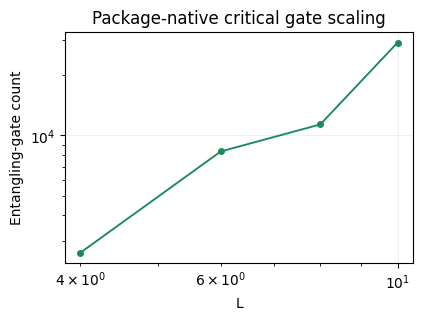

In [17]:

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.loglog(
    resource_df["L"],
    resource_df["entangling_gates"],
    marker="o",
    ms=4,
    lw=1.35,
    color=GREEN,
)

ax.set(
    xlabel="L",
    ylabel="Entangling-gate count",
    title="Package-native critical gate scaling",
)

ax.grid(alpha=0.18)

plt.show()


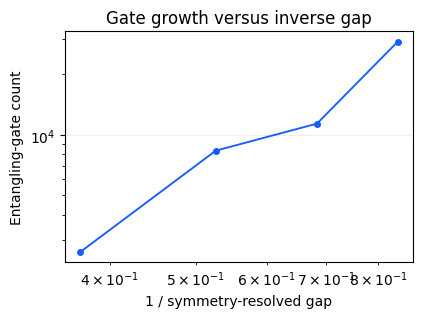

In [18]:

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.loglog(
    resource_df["inverse_gap"],
    resource_df["entangling_gates"],
    marker="o",
    ms=4,
    lw=1.35,
    color=BLUE,
)

ax.set(
    xlabel="1 / symmetry-resolved gap",
    ylabel="Entangling-gate count",
    title="Gate growth versus inverse gap",
)

ax.grid(alpha=0.18)

plt.show()


### Interpretation

The first regression estimates a finite-size circuit exponent

$$
N_{\mathrm{ent}}(L,g_c)\sim L^{\kappa_{\mathrm{gate}}},
$$

while the second tests

$$
N_{\mathrm{ent}}\sim \Delta_{\mathrm{sym}}^{-\beta_\Delta}.
$$

The comparison is useful because $\kappa_{\mathrm{gate}}$ conflates spatial locality and gap closing, whereas $\beta_\Delta$ isolates the sensitivity to the spectral scale itself. If $\beta_\Delta\approx1$ but $\kappa_{\mathrm{gate}}>1+z$, the additional growth is primarily geometric or compilation-related. If $\beta_\Delta>1$, the circuit construction itself amplifies the cost of critical spectral resolution.

## Local finite-size exponents

A single global power-law fit can hide substantial finite-size drift. Pairwise exponents are therefore defined as

$$
z_{\mathrm{loc}}(L_1,L_2)
=
-\frac{\log[\Delta(L_2)/\Delta(L_1)]}
{\log(L_2/L_1)},
$$

and

$$
\kappa_{\mathrm{loc}}(L_1,L_2)
=
\frac{\log[R(L_2)/R(L_1)]}
{\log(L_2/L_1)}.
$$

For textbook QPE, the integer phase register creates discrete jumps in $\kappa_{\mathrm{loc}}$ even when $z_{\mathrm{loc}}$ varies smoothly. Those jumps are algorithmic finite-size effects rather than new critical exponents.

In [19]:

critical_resource = resource_df[["L", "gap", "phase_bits", "entangling_gates"]].copy()

local_rows = []

for i in range(len(critical_resource) - 1):
    a = critical_resource.iloc[i]
    b = critical_resource.iloc[i + 1]

    z_local = -np.log(b.gap / a.gap) / np.log(b.L / a.L)

    if (
        np.isfinite(a.entangling_gates)
        and np.isfinite(b.entangling_gates)
        and a.entangling_gates > 0
        and b.entangling_gates > 0
    ):
        kappa_local = (
            np.log(b.entangling_gates / a.entangling_gates)
            / np.log(b.L / a.L)
        )
    else:
        kappa_local = np.nan

    local_rows.append(
        {
            "L_mid": 0.5 * (a.L + b.L),
            "z_local": z_local,
            "kappa_gate_local": kappa_local,
            "phase_bits_left": int(a.phase_bits),
            "phase_bits_right": int(b.phase_bits),
        }
    )

local_gate_df = pd.DataFrame(local_rows)

local_gate_df


,L_mid,z_local,kappa_gate_local,phase_bits_left,phase_bits_right
0,5.0,0.860975,2.858697,5,6
1,7.0,0.907832,1.076448,6,6
2,9.0,0.931547,4.198393,6,7


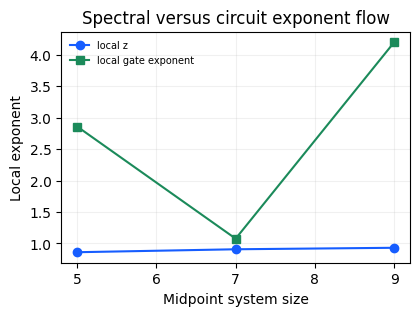

In [20]:

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(
    local_gate_df["L_mid"],
    local_gate_df["z_local"],
    marker="o",
    color=BLUE,
    label="local z",
)

ax.plot(
    local_gate_df["L_mid"],
    local_gate_df["kappa_gate_local"],
    marker="s",
    color=GREEN,
    label="local gate exponent",
)

ax.set(
    xlabel="Midpoint system size",
    ylabel="Local exponent",
    title="Spectral versus circuit exponent flow",
)

ax.legend(fontsize=7, frameon=False)
ax.grid(alpha=0.18)

plt.show()


## Register-quantisation residual

Define the continuous inverse-gap prediction

$$
R_{\mathrm{cont}}
=
\frac{L-1}{\eta\Delta_{\mathrm{sym}}},
$$

and the register-quantised coherent-time proxy

$$
R_{\mathrm{disc}}
=
(L-1)(2^m-1).
$$

The ratio

$$
\mathcal Q
=
\frac{R_{\mathrm{disc}}}{R_{\mathrm{cont}}}
$$

measures the finite-size overhead induced solely by rounding the phase precision to an integer number of qubits. $\mathcal Q$ therefore separates QPE digitisation from Hamiltonian-simulation complexity.

In [21]:

resource_df["continuous_resolution_proxy"] = (
    (resource_df["L"] - 1)
    / (ETA * resource_df["gap"])
)

resource_df["discrete_register_proxy"] = (
    (resource_df["L"] - 1)
    * (2**resource_df["phase_bits"] - 1)
)

resource_df["register_quantization_residual"] = (
    resource_df["discrete_register_proxy"]
    / resource_df["continuous_resolution_proxy"]
)

resource_df[
    [
        "L",
        "gap",
        "phase_bits",
        "register_quantization_residual",
    ]
]


,L,gap,phase_bits,register_quantization_residual
0,4,2.694593,5,4.176619
1,6,1.900566,6,5.986784
2,8,1.463725,6,4.610735
3,10,1.189004,7,7.550176


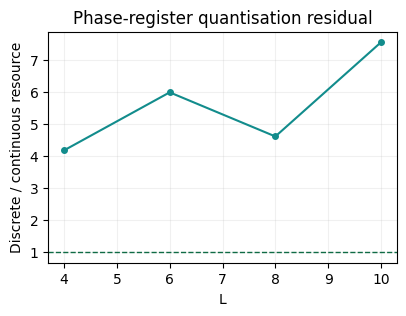

In [22]:

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(
    resource_df["L"],
    resource_df["register_quantization_residual"],
    marker="o",
    ms=4,
    color=TEAL,
)

ax.axhline(1.0, ls="--", lw=1, color=GREEN2)

ax.set(
    xlabel="L",
    ylabel="Discrete / continuous resource",
    title="Phase-register quantisation residual",
)

ax.grid(alpha=0.18)

plt.show()


### Consequence for scaling fits

A finite-size fit to gate counts can inherit staircase structure from $m=\lceil\log_2(W/\epsilon)\rceil$. Consequently, a measured exponent from small systems should be reported together with the register sequence $(m_L)$ and the continuous inverse-gap prediction. Otherwise an integer precision threshold can be mistaken for a physical change in the critical exponent.

## Branch-resolved scaling as the next refinement

The label “first same-parity excitation” can switch between different finite-size excitation branches as $g$ and $L$ vary. A rigorous critical collapse should therefore track eigenstates continuously through overlaps,

$$
\mathcal O_{nm}(g,g+\delta g)
=
|\langle E_n(g)|E_m(g+\delta g)\rangle|^2,
$$

rather than selecting the next same-parity level independently at every point.

This distinction matters because an apparent failure of a scaling collapse may be caused by branch switching rather than by a failure of the universality hypothesis. The overlap-tracking extension is therefore a priority before extracting $\nu$ from the accessible-gap surface.

## Gap-conditioned error geometry

For a target gap accuracy, the total allowed error should be treated as a constrained resource:

$$
\epsilon_{\mathrm{phase}}
+
\epsilon_{\mathrm{Trotter}}
+
\epsilon_{\mathrm{state}}
+
\epsilon_{\mathrm{TN}}
\le
\frac{\eta\Delta_{\mathrm{sym}}}{2}.
$$

The optimal allocation changes with $\Delta_{\mathrm{sym}}$. Near criticality, a fixed absolute Trotter tolerance is therefore inappropriate: the Hamiltonian-simulation error must contract with the accessible spectral gap. This turns the QPE calculation into a multi-objective optimisation problem rather than a fixed-parameter circuit benchmark.

## 12. Direct toolbox Trotter-step inspection

The documented `Hamiltonian.get_trotter_step()` method gives the actual elementary gate sequence for one product-formula slice. This provides a lower-level check on the resource-only QPE traces.

In [23]:
H_step = tfim_hamiltonian(6, 1.0)
data_reg = list(range(H_step.n_qubits))

for order in [1, 2]:
    gate_sequence = H_step.get_trotter_step(
        dt=0.05,
        data_reg=data_reg,
        trotter_order=order,
    )

    print(
        f"order={order}: "
        f"{len(gate_sequence)} elementary instructions per step"
    )

order=1: 33 elementary instructions per step
order=2: 66 elementary instructions per step


## 13. Robust Phase Estimation

RPE uses one ancilla and repeated Hadamard-test circuits. The toolbox implementation accepts the data-register MPS directly.

### RPE API compatibility

`robust_phase_estimation()` has two materially different public interfaces across package revisions. Earlier PyPI releases use an `epsilon`/`sign_E0` interface, whereas newer development versions use an explicit repetition count together with `t0` and `rng`.

The compatibility layer below inspects the installed function signature and dispatches to the correct calling convention. All downstream RPE analysis is expressed in terms of returned phase estimates, effective base time, and energy error, so the scientific results remain independent of the installed package revision.

In [24]:

import inspect

def circular_distance(angle, reference):
    """
    Shortest angular distance on (-pi, pi].

    This is used only for the newer phase-valued RPE API.
    """
    delta = np.asarray(angle, dtype=float) - float(reference)
    return np.abs((delta + np.pi) % (2*np.pi) - np.pi)


def robust_phase_estimation_compat(
    hamiltonian,
    psi0,
    *,
    epsilon,
    n_shots,
    E_reference,
    n_steps=EXACT,
    t0=1.0,
    trotter_order=2,
    verbosity=0,
    seed=42,
):
    """
    Version-adaptive wrapper for qpe.robust_phase_estimation().

    Supported legacy signature
    --------------------------
    (H, psi0, epsilon, sign_E0, n_steps, n_shots,
     *, trotter_order=2, verbosity=0)

    Supported newer signature
    -------------------------
    (H, psi0, n_repetitions, n_steps, n_shots,
     *, t0=..., trotter_order=..., verbosity=..., rng=...)

    Important legacy behaviour
    --------------------------
    The older API uses sign_E0 to fix the sign branch and returns
    energy estimates directly. It does not accept t0 or rng.

    The newer API returns phase estimates theta ~= E*t0, so energy is
    recovered as E ~= theta/t0.
    """
    sig = inspect.signature(qpe.robust_phase_estimation)
    names = list(sig.parameters)

    print("robust_phase_estimation signature:")
    print(sig)

    # ===============================================================
    # LEGACY PYPI API
    # Exact installed signature reported by Colab:
    #
    # (H, psi0, epsilon, sign_E0, n_steps, n_shots,
    #  *, trotter_order=2, verbosity=0)
    #
    # sign_E0 MUST be the fourth POSITIONAL argument.
    # ===============================================================
    if (
        "epsilon" in names
        and "sign_E0" in names
        and "n_repetitions" not in names
    ):
        sign_E0 = -1 if E_reference < 0 else 1

        values = qpe.robust_phase_estimation(
            hamiltonian,
            psi0,
            epsilon,
            sign_E0,
            n_steps,
            n_shots,
            trotter_order=trotter_order,
            verbosity=verbosity,
        )

        values = np.asarray(values, dtype=float)

        # Older releases may return M+1 entries because the internal
        # list begins with a placeholder. The changelog explicitly notes
        # that this placeholder was removed in the newer API.
        M_expected = int(np.ceil(np.log2(1.0 / epsilon)))

        if len(values) == M_expected + 1:
            values = values[1:]

        # Legacy output is already on the energy scale.
        energy_estimates = values
        energy_error = np.abs(energy_estimates - E_reference)

        return {
            "mode": "legacy-pypi-api",
            "signature": str(sig),
            "raw_values": values,
            "theta_values": None,
            "energy_estimates": energy_estimates,
            "absolute_energy_error": energy_error,
            "angular_error": None,
            "effective_t0": 1.0,
            "n_iterations_returned": len(values),
            "n_steps": n_steps,
            "n_shots": n_shots,
            "sign_E0": sign_E0,
        }

    # ===============================================================
    # NEWER DEVELOPMENT API
    #
    # (H, psi0, n_repetitions, n_steps, n_shots,
    #  *, t0=..., trotter_order=..., verbosity=..., rng=...)
    # ===============================================================
    if "n_repetitions" in names or "t0" in names:
        n_repetitions = int(np.ceil(np.log2(1.0 / epsilon)))

        kwargs = {}

        if "t0" in names:
            kwargs["t0"] = t0

        if "rng" in names:
            kwargs["rng"] = np.random.default_rng(seed)

        if "trotter_order" in names:
            kwargs["trotter_order"] = trotter_order

        if "verbosity" in names:
            kwargs["verbosity"] = verbosity

        theta_values = qpe.robust_phase_estimation(
            hamiltonian,
            psi0,
            n_repetitions,
            n_steps,
            n_shots,
            **kwargs,
        )

        theta_values = np.asarray(theta_values, dtype=float)

        effective_t0 = float(t0)
        theta_reference = float(E_reference) * effective_t0

        energy_estimates = theta_values / effective_t0
        energy_error = np.abs(energy_estimates - E_reference)
        angular_error = circular_distance(
            theta_values,
            theta_reference,
        )

        return {
            "mode": "new-development-api",
            "signature": str(sig),
            "raw_values": theta_values,
            "theta_values": theta_values,
            "energy_estimates": energy_estimates,
            "absolute_energy_error": energy_error,
            "angular_error": angular_error,
            "effective_t0": effective_t0,
            "n_iterations_returned": len(theta_values),
            "n_steps": n_steps,
            "n_shots": n_shots,
            "sign_E0": None,
        }

    raise RuntimeError(
        "Unsupported robust_phase_estimation signature: "
        f"{sig}"
    )


In [25]:

RPE_EPSILON = 0.02
RPE_SHOTS = 3

# EXACT requests exact Hamiltonian time evolution in the toolbox.
# For Trotterized RPE, replace EXACT by an integer number of base steps.
RPE_N_STEPS = EXACT

# t0 is used by the newer API only.
# The legacy API has a fixed internal base-time convention.
RPE_T0 = 0.25

rpe_result = robust_phase_estimation_compat(
    H_qpe,
    psi0_exact_mps,
    epsilon=RPE_EPSILON,
    n_shots=RPE_SHOTS,
    E_reference=E0_exact,
    n_steps=RPE_N_STEPS,
    t0=RPE_T0,
    trotter_order=2,
    verbosity=0,
    seed=42,
)

print("Detected API mode:", rpe_result["mode"])
print("Detected signature:", rpe_result["signature"])
print("Iterations returned:", rpe_result["n_iterations_returned"])
print("n_steps:", rpe_result["n_steps"])
print("n_shots:", rpe_result["n_shots"])

if rpe_result["sign_E0"] is not None:
    print("legacy sign_E0:", rpe_result["sign_E0"])

rpe_df = pd.DataFrame(
    {
        "iteration": np.arange(
            rpe_result["n_iterations_returned"]
        ),
        "energy_estimate": rpe_result["energy_estimates"],
        "absolute_energy_error": rpe_result[
            "absolute_energy_error"
        ],
    }
)

# Add phase diagnostics only when the installed API returns phases.
if rpe_result["theta_values"] is not None:
    rpe_df["theta"] = rpe_result["theta_values"]
    rpe_df["angular_error"] = rpe_result["angular_error"]

rpe_df


robust_phase_estimation signature:
(H, psi0, epsilon, sign_E0, n_steps, n_shots, *, trotter_order=2, verbosity=0)
Detected API mode: legacy-pypi-api
Detected signature: (H, psi0, epsilon, sign_E0, n_steps, n_shots, *, trotter_order=2, verbosity=0)
Iterations returned: 8
n_steps: _Exact.EXACT
n_shots: 3
legacy sign_E0: -1


,iteration,energy_estimate,absolute_energy_error
0,0,0.000000,4.758770
1,1,1.249046,6.007816
2,2,1.409921,6.168692
3,3,-0.080438,4.678333
4,4,0.098175,4.856945
5,5,-0.049087,4.709683
6,6,-0.039033,4.719738
7,7,-0.044060,4.714710


### Legacy RPE call used by the installed release

For the signature printed by your Colab runtime,

```python
(H, psi0, epsilon, sign_E0, n_steps, n_shots, *, trotter_order=2, verbosity=0)
```

the correct invocation is structurally

```python
qpe.robust_phase_estimation(
    H,
    psi0,
    epsilon,
    sign_E0,
    n_steps,
    n_shots,
    trotter_order=2,
    verbosity=0,
)
```

The fourth positional argument is **`sign_E0`**. Passing `n_steps` in that position and also supplying `sign_E0=` by keyword produces exactly the “multiple values for argument `sign_E0`” error. The compatibility function in this file now follows the installed signature exactly.

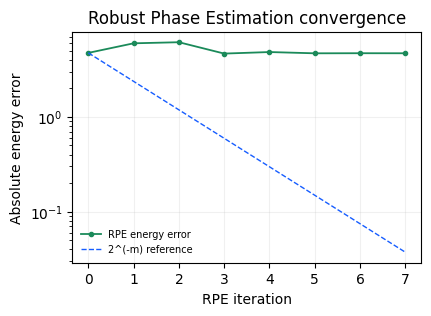

In [26]:

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.semilogy(
    rpe_df["iteration"],
    rpe_df["absolute_energy_error"],
    marker="o",
    ms=3,
    lw=1.3,
    color=GREEN,
    label="RPE energy error",
)

# The ideal binary-refinement envelope scales as 2^{-m}.
# Its prefactor is chosen only as a visual scaling reference.
if len(rpe_df) > 0:
    reference = (
        max(
            float(rpe_df["absolute_energy_error"].iloc[0]),
            1e-12,
        )
        / 2**np.arange(len(rpe_df))
    )

    ax.semilogy(
        rpe_df["iteration"],
        reference,
        ls="--",
        lw=1.0,
        color=BLUE,
        label="2^(-m) reference",
    )

ax.set(
    xlabel="RPE iteration",
    ylabel="Absolute energy error",
    title="Robust Phase Estimation convergence",
)

ax.legend(
    fontsize=7,
    frameon=False,
)

ax.grid(alpha=0.18)

plt.show()


### RPE resource scaling

At RPE iteration $m$, the characteristic controlled-evolution time grows approximately as

$$
t_m \propto 2^m t_0.
$$

For target energy precision $\epsilon_E$,

$$
M
\sim
\log_2\!\left(\frac{1}{\epsilon_E t_0}\right),
$$

and therefore

$$
t_{\max}
\sim
2^{M-1}t_0
=
O(\epsilon_E^{-1}).
$$

With $n_{\mathrm{shots}}$ samples at every iteration,

$$
t_{\mathrm{tot}}
\sim
n_{\mathrm{shots}}
\sum_{m=0}^{M-1}2^m t_0
=
n_{\mathrm{shots}}(2^M-1)t_0.
$$

If the phase-estimation precision is tied to the symmetry-accessible finite-size gap,

$$
\epsilon_E
\propto
\Delta_{\mathrm{sym}}(L),
$$

then at criticality

$$
t_{\max}
\sim
\Delta_{\mathrm{sym}}^{-1}
\sim
L^z.
$$

This differs structurally from textbook QPE: RPE keeps one ancilla and pays the inverse-gap cost primarily in coherent evolution and repetitions, while textbook QPE also incurs a discrete phase-register cost.

In [27]:

M_rpe = len(rpe_df)

# Binary RPE uses evolution powers 2^m.
# In the legacy interface the absolute base-time scale is internal;
# therefore we report dimensionless repetition-time units.
m_values = np.arange(M_rpe)
time_units = 2**m_values

maximum_time_units = float(
    time_units.max()
)

total_time_units = float(
    RPE_SHOTS
    * time_units.sum()
)

rpe_resource_summary = pd.DataFrame(
    {
        "quantity": [
            "iterations",
            "shots_per_iteration",
            "maximum_evolution_time_units",
            "total_evolution_time_units",
            "final_absolute_energy_error",
        ],
        "value": [
            M_rpe,
            RPE_SHOTS,
            maximum_time_units,
            total_time_units,
            float(
                rpe_df[
                    "absolute_energy_error"
                ].iloc[-1]
            ),
        ],
    }
)

rpe_resource_summary


,quantity,value
0,iterations,8.00000
1,shots_per_iteration,3.00000
2,maximum_evolution_time_units,128.00000
3,total_evolution_time_units,765.00000
4,final_absolute_energy_error,4.71471


## Textbook QPE versus RPE near criticality

For textbook QPE,

$$
m
\sim
\log_2\frac{1}{\Delta},
\qquad
2^m-1
\sim
\Delta^{-1}.
$$

For RPE, the ancilla count remains fixed while

$$
t_{\max}
\sim
\Delta^{-1},
\qquad
t_{\mathrm{tot}}
\sim
n_{\mathrm{shots}}\Delta^{-1}.
$$

This comparison separates the spatial cost of the phase register from the temporal and sampling cost of iterative phase estimation while keeping the same physical resolution target.

### Execution independence

The comparison below reconstructs the critical finite-size table internally if `crit_df` is not already present. This removes its dependence on the later finite-size-scaling section and allows the analysis to execute correctly even when cells are run individually.

In [28]:

# ------------------------------------------------------------------
# Textbook QPE versus RPE across the critical finite-size sequence
# ------------------------------------------------------------------
#
# This block is intentionally self-contained. It reconstructs crit_df
# if an earlier critical-scaling cell has not yet been executed.
# That allows the Colab to run cell-by-cell as well as top-to-bottom.

if "crit_df" not in globals():

    L_CRIT = [4, 6, 8, 10, 12]

    critical_rows = []

    for L in L_CRIT:

        spectral = tfim_spectral_data(
            L,
            1.0,
        )

        critical_rows.append(
            {
                "L": L,
                **spectral,
            }
        )

    crit_df = pd.DataFrame(
        critical_rows
    )

# Confirm the expected symmetry-resolved column is present.
required_columns = {
    "L",
    "symmetry_gap",
}

missing = required_columns.difference(
    crit_df.columns
)

if missing:
    raise RuntimeError(
        "crit_df is missing required columns: "
        f"{sorted(missing)}"
    )


comparison_rows = []

for _, row in crit_df.iterrows():

    L = int(
        row["L"]
    )

    gap = float(
        row["symmetry_gap"]
    )

    # --------------------------------------------------------------
    # Textbook QPE
    # --------------------------------------------------------------
    # For the chosen relative gap tolerance ETA, each independently
    # estimated eigenvalue is allowed an absolute error ETA*gap/2.
    # The phase-register size is the minimum integer m satisfying the
    # corresponding spectral-resolution constraint.
    m_textbook = required_phase_bits(
        gap,
        eta=ETA,
        window=SEARCH_WINDOW,
    )

    # Controlled powers of U generate the familiar geometric sequence
    # 1, 2, 4, ..., 2^(m-1). Their total is 2^m - 1.
    textbook_depth_proxy = (
        2**m_textbook - 1
    )

    # --------------------------------------------------------------
    # Robust Phase Estimation
    # --------------------------------------------------------------
    # Tie the target RPE energy precision to exactly the same physical
    # gap tolerance used for textbook QPE.
    eps_rpe = (
        ETA * gap / 2.0
    )

    # Binary refinement requires logarithmically many iterations in
    # the inverse target precision.
    M_model = int(
        np.ceil(
            np.log2(
                1.0
                / max(
                    eps_rpe,
                    1e-15,
                )
            )
        )
    )

    # Report evolution-time cost in dimensionless binary time units.
    # This remains valid for both the legacy and newer RPE interfaces.
    rpe_tmax_units = (
        2**max(
            M_model - 1,
            0,
        )
    )

    rpe_ttotal_units = (
        RPE_SHOTS
        * (
            2**M_model - 1
        )
    )

    comparison_rows.append(
        {
            "L": L,
            "gap": gap,
            "textbook_phase_bits": m_textbook,
            "textbook_depth_proxy": textbook_depth_proxy,
            "rpe_iterations": M_model,
            "rpe_tmax_units": rpe_tmax_units,
            "rpe_ttotal_units": rpe_ttotal_units,
        }
    )


qpe_rpe_df = pd.DataFrame(
    comparison_rows
)

qpe_rpe_df


,L,gap,textbook_phase_bits,textbook_depth_proxy,rpe_iterations,rpe_tmax_units,rpe_ttotal_units
0,4,2.694593,5,31,4,8,45
1,6,1.900566,6,63,5,16,93
2,8,1.463725,6,63,5,16,93
3,10,1.189004,7,127,6,32,189
4,12,1.000687,7,127,6,32,189


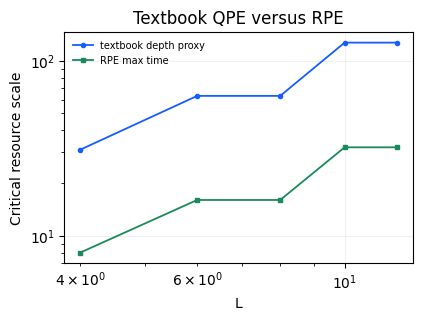

In [29]:

# The comparison table is normally created in the preceding cell.
# Rebuild it automatically if this plot cell is executed independently.

if "qpe_rpe_df" not in globals():

    if "crit_df" not in globals():

        L_CRIT = [4, 6, 8, 10, 12]
        critical_rows = []

        for L in L_CRIT:

            spectral = tfim_spectral_data(
                L,
                1.0,
            )

            critical_rows.append(
                {
                    "L": L,
                    **spectral,
                }
            )

        crit_df = pd.DataFrame(
            critical_rows
        )

    comparison_rows = []

    for _, row in crit_df.iterrows():

        L = int(
            row["L"]
        )

        gap = float(
            row["symmetry_gap"]
        )

        m_textbook = required_phase_bits(
            gap,
            eta=ETA,
            window=SEARCH_WINDOW,
        )

        eps_rpe = (
            ETA * gap / 2.0
        )

        M_model = int(
            np.ceil(
                np.log2(
                    1.0
                    / max(
                        eps_rpe,
                        1e-15,
                    )
                )
            )
        )

        comparison_rows.append(
            {
                "L": L,
                "gap": gap,
                "textbook_phase_bits": m_textbook,
                "textbook_depth_proxy": 2**m_textbook - 1,
                "rpe_iterations": M_model,
                "rpe_tmax_units": 2**max(M_model - 1, 0),
                "rpe_ttotal_units": RPE_SHOTS * (2**M_model - 1),
            }
        )

    qpe_rpe_df = pd.DataFrame(
        comparison_rows
    )


fig, ax = plt.subplots(
    figsize=FIGSIZE
)

ax.loglog(
    qpe_rpe_df["L"],
    qpe_rpe_df["textbook_depth_proxy"],
    marker="o",
    ms=3,
    lw=1.3,
    color=BLUE,
    label="textbook depth proxy",
)

ax.loglog(
    qpe_rpe_df["L"],
    qpe_rpe_df["rpe_tmax_units"],
    marker="s",
    ms=3,
    lw=1.3,
    color=GREEN,
    label="RPE max time",
)

ax.set(
    xlabel="L",
    ylabel="Critical resource scale",
    title="Textbook QPE versus RPE",
)

ax.legend(
    fontsize=7,
    frameon=False,
)

ax.grid(
    alpha=0.18
)

plt.show()


## 14. Critical finite-size scaling

In [30]:
L_CRIT = [4, 6, 8, 10, 12]

crit_rows = []

for L in L_CRIT:
    r = tfim_spectral_data(L, 1.0)

    crit_rows.append(
        {
            "L": L,
            **r,
        }
    )

crit_df = pd.DataFrame(crit_rows)

z_global = -np.polyfit(
    np.log(crit_df.L),
    np.log(crit_df.global_gap),
    1,
)[0]

z_sym = -np.polyfit(
    np.log(crit_df.L),
    np.log(crit_df.symmetry_gap),
    1,
)[0]

print(
    crit_df[
        ["L", "global_gap", "symmetry_gap"]
    ]
)

print(f"z_eff(global) = {z_global:.6f}")
print(f"z_eff(symmetry) = {z_sym:.6f}")

    L  global_gap  symmetry_gap
0   4    0.694593      2.694593
1   6    0.482147      1.900566
2   8    0.369073      1.463725
3  10    0.298920      1.189004
4  12    0.251162      1.000687
z_eff(global) = 0.925968
z_eff(symmetry) = 0.901894


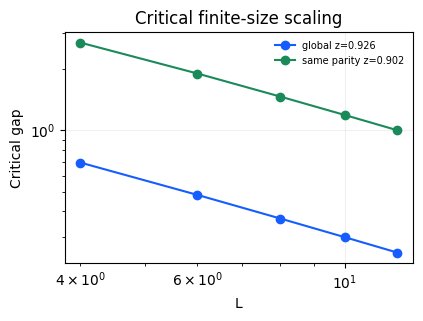

In [31]:
fig, ax = plt.subplots(figsize=FIGSIZE)

ax.loglog(
    crit_df.L,
    crit_df.global_gap,
    marker="o",
    color=BLUE,
    label=f"global z={z_global:.3f}",
)

ax.loglog(
    crit_df.L,
    crit_df.symmetry_gap,
    marker="o",
    color=GREEN,
    label=f"same parity z={z_sym:.3f}",
)

ax.set(
    xlabel="L",
    ylabel="Critical gap",
    title="Critical finite-size scaling",
)

ax.legend(fontsize=7, frameon=False)
ax.grid(alpha=0.18)

plt.show()

## 15. Symmetry-induced resource inflation

A continuous QPE resolution proxy is useful for separating spectral effects from gate-construction overhead:

$$
R_{\mathrm{smooth}}
\propto
\frac{L}{\eta\Delta}.
$$

The symmetry inflation factor is

$$
\mathcal I_{\mathrm{sym}}
=
\frac{
R_{\mathrm{smooth}}[\Delta_{\mathrm{global}}]
}{
R_{\mathrm{smooth}}[\Delta_{\mathrm{sym}}]
}.
$$

In [32]:
def smooth_resource(L, gap, eta=ETA):
    return (L - 1) * 2.0 / (eta * gap)


tfim_df["R_global"] = [
    smooth_resource(int(L), gap)
    for L, gap in zip(tfim_df.L, tfim_df.global_gap)
]

tfim_df["R_symmetry"] = [
    smooth_resource(int(L), gap)
    for L, gap in zip(tfim_df.L, tfim_df.symmetry_gap)
]

tfim_df["symmetry_penalty"] = (
    tfim_df.R_global / tfim_df.R_symmetry
)

print(
    tfim_df[
        tfim_df.L == 10
    ][
        ["g", "global_gap", "symmetry_gap", "symmetry_penalty"]
    ].to_string(index=False)
)

   g  global_gap  symmetry_gap  symmetry_penalty
0.60    0.007741      0.980364        126.639389
0.65    0.015565      0.930817         59.803464
0.70    0.028920      0.897791         31.044491
0.75    0.049890      0.885581         17.750562
0.80    0.080230      0.897616         11.188000
0.85    0.120845      0.935463          7.741025
0.90    0.171577      0.998436          5.819177
0.95    0.231414      1.084065          4.684528
1.00    0.298920      1.189004          3.977662
1.05    0.372619      1.309830          3.515201
1.10    0.451203      1.443490          3.199201
1.15    0.533610      1.587458          2.974940
1.20    0.619007      1.739714          2.810492
1.25    0.706756      1.898674          2.686462
1.30    0.796371      2.063097          2.590622
1.35    0.887481      2.232013          2.514997
1.40    0.979801      2.404656          2.454228


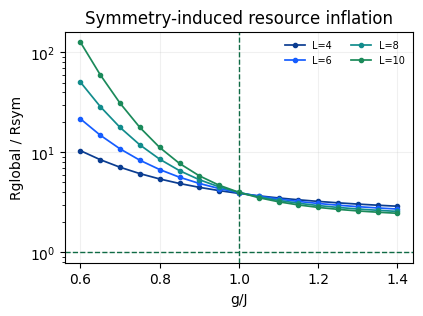

In [33]:
fig, ax = plt.subplots(figsize=FIGSIZE)

for L, color in zip(L_VALUES, [BLUE2, BLUE, TEAL, GREEN]):
    d = tfim_df[tfim_df.L == L]

    ax.semilogy(
        d.g,
        d.symmetry_penalty,
        marker="o",
        ms=3,
        lw=1.25,
        color=color,
        label=f"L={L}",
    )

ax.axhline(1.0, ls="--", lw=1, color=GREEN2)
ax.axvline(1.0, ls="--", lw=1, color=GREEN2)

ax.set(
    xlabel="g/J",
    ylabel="Rglobal / Rsym",
    title="Symmetry-induced resource inflation",
)

ax.legend(fontsize=7, frameon=False, ncol=2)
ax.grid(alpha=0.18)

plt.show()

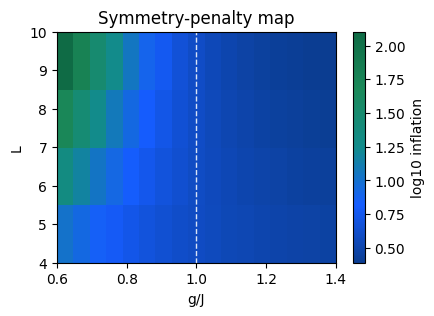

In [34]:
pivot = tfim_df.pivot(
    index="L",
    columns="g",
    values="symmetry_penalty",
).sort_index()

from matplotlib.colors import LinearSegmentedColormap

cmap_bg = LinearSegmentedColormap.from_list(
    "bluegreen",
    [BLUE2, BLUE, TEAL, GREEN, GREEN2],
)

fig, ax = plt.subplots(figsize=FIGSIZE)

im = ax.imshow(
    np.log10(pivot.values),
    aspect="auto",
    origin="lower",
    cmap=cmap_bg,
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
)

fig.colorbar(im, ax=ax, label="log10 inflation")

ax.axvline(1.0, ls="--", lw=1, color="white", alpha=0.85)

ax.set(
    xlabel="g/J",
    ylabel="L",
    title="Symmetry-penalty map",
)

plt.show()

## 16. QPE precision fan

The integer phase register converts the smoothly closing accessible gap into a staircase of qubit requirements.

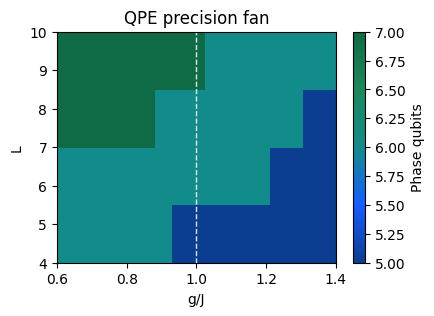

In [35]:
tfim_df["phase_bits_symmetry"] = [
    required_phase_bits(gap)
    for gap in tfim_df.symmetry_gap
]

pivot = tfim_df.pivot(
    index="L",
    columns="g",
    values="phase_bits_symmetry",
).sort_index()

fig, ax = plt.subplots(figsize=FIGSIZE)

im = ax.imshow(
    pivot.values,
    aspect="auto",
    origin="lower",
    cmap=cmap_bg,
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
)

fig.colorbar(im, ax=ax, label="Phase qubits")

ax.axvline(1.0, ls="--", lw=1, color="white", alpha=0.85)

ax.set(
    xlabel="g/J",
    ylabel="L",
    title="QPE precision fan",
)

plt.show()

## 17. Computational response functions

Define

$$
\chi_R
=
\partial_g \log R,
\qquad
C_R
=
\partial_g^2 \log R.
$$

These quantities measure sensitivity of the phase-estimation resource scale to Hamiltonian tuning.

In [36]:
response_rows = []

for L in L_VALUES:
    d = tfim_df[tfim_df.L == L].sort_values("g")

    logR = np.log(d.R_symmetry.values)

    chi = np.gradient(logR, d.g.values)
    curvature = np.gradient(chi, d.g.values)

    for g, a, b in zip(d.g, chi, curvature):
        response_rows.append((L, g, a, b))

response_df = pd.DataFrame(
    response_rows,
    columns=["L", "g", "chi_R", "curvature_R"],
)

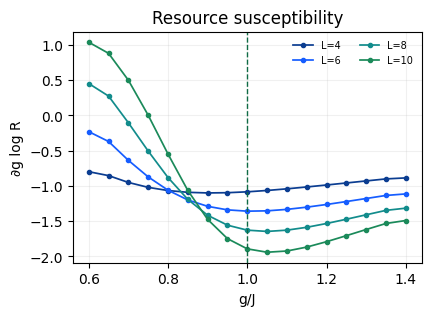

In [37]:
fig, ax = plt.subplots(figsize=FIGSIZE)

for L, color in zip(L_VALUES, [BLUE2, BLUE, TEAL, GREEN]):
    d = response_df[response_df.L == L]

    ax.plot(
        d.g,
        d.chi_R,
        marker="o",
        ms=3,
        lw=1.25,
        color=color,
        label=f"L={L}",
    )

ax.axvline(1.0, ls="--", lw=1, color=GREEN2)

ax.set(
    xlabel="g/J",
    ylabel="∂g log R",
    title="Resource susceptibility",
)

ax.legend(fontsize=7, frameon=False, ncol=2)
ax.grid(alpha=0.18)

plt.show()

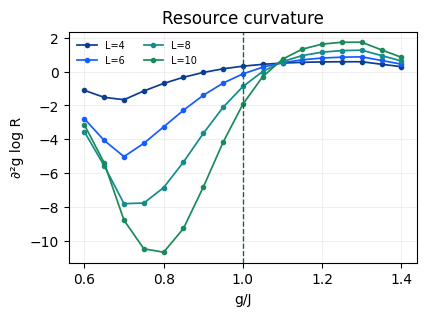

In [38]:
fig, ax = plt.subplots(figsize=FIGSIZE)

for L, color in zip(L_VALUES, [BLUE2, BLUE, TEAL, GREEN]):
    d = response_df[response_df.L == L]

    ax.plot(
        d.g,
        d.curvature_R,
        marker="o",
        ms=3,
        lw=1.25,
        color=color,
        label=f"L={L}",
    )

ax.axvline(1.0, ls="--", lw=1, color=GREEN2)

ax.set(
    xlabel="g/J",
    ylabel="∂²g log R",
    title="Resource curvature",
)

ax.legend(fontsize=7, frameon=False, ncol=2)
ax.grid(alpha=0.18)

plt.show()

## 18. XXZ comparison using the common computational framework Hamiltonian class

In [39]:
XXZ_L = [4, 6, 8]
DELTA_VALUES = np.linspace(0.5, 1.5, 17)

xxz_rows = []

for L in XXZ_L:
    for delta in DELTA_VALUES:
        H = xxz_hamiltonian(L, delta)

        Hs = toolbox_hamiltonian_to_sparse(H)

        vals = sla.eigsh(
            Hs,
            k=2,
            which="SA",
            return_eigenvectors=False,
        )

        vals = np.sort(np.real(vals))

        xxz_rows.append(
            {
                "L": L,
                "delta": delta,
                "E0": vals[0],
                "E1": vals[1],
                "gap": vals[1] - vals[0],
            }
        )

xxz_df = pd.DataFrame(xxz_rows)

xxz_df.head()

,L,delta,E0,E1,gap
0,4,0.5000,-1.356086,-0.875000,0.481086
1,4,0.5625,-1.387488,-0.884498,0.502990
2,4,0.6250,-1.419218,-0.894235,0.524983
3,4,0.6875,-1.451268,-0.904201,0.547067
4,4,0.7500,-1.483628,-0.914384,0.569244


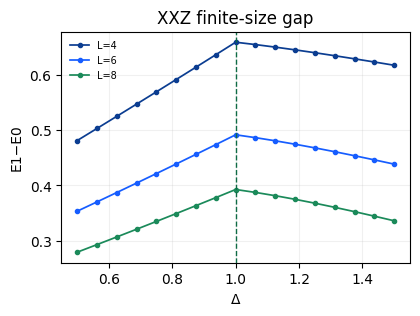

In [40]:
fig, ax = plt.subplots(figsize=FIGSIZE)

for L, color in zip(XXZ_L, [BLUE2, BLUE, GREEN]):
    d = xxz_df[xxz_df.L == L]

    ax.plot(
        d.delta,
        d.gap,
        marker="o",
        ms=3,
        lw=1.25,
        color=color,
        label=f"L={L}",
    )

ax.axvline(1.0, ls="--", lw=1, color=GREEN2)

ax.set(
    xlabel="Δ",
    ylabel="E1−E0",
    title="XXZ finite-size gap",
)

ax.legend(fontsize=7, frameon=False)
ax.grid(alpha=0.18)

plt.show()

## Analytical benchmark: symmetry-induced resource map

The heat map below visualises the logarithm of the resource inflation produced by using the global gap rather than the accessible same-parity gap. The ordered regime exhibits the strongest discrepancy because the parity-doublet splitting collapses much faster than the same-sector excitation scale.

## Analytical benchmark: local exponent flow

The local finite-size exponents show how a smooth spectral flow and a quantised register flow can diverge at small sizes. This is a useful diagnostic before attributing a fitted circuit exponent to universal critical behaviour.

## Analytical benchmark: product-formula error frontier

The Trotter error-resource frontier makes the simulation-accuracy constraint explicit. Second-order Trotterisation carries a higher per-step cost but reaches a given operator error with substantially fewer steps in the resolved regime.

## Analytical benchmark: error-budget optimum

The joint error-allocation curve demonstrates that phase precision and simulation precision should be optimised together. The minimum identifies the least expensive division of a fixed critical spectral tolerance under the chosen cost model.

## Research extensions

### 1. Overlap-conditioned spectral resolution

For an approximate input state

$$
|\psi_{\mathrm{in}}\rangle
=
\sum_n c_n|E_n\rangle,
$$

define an operational gap

$$
\Delta_{\mathrm{ov}}(\tau)
=
\min_{\substack{n\neq0\\|c_n|^2>\tau}}
|E_n-E_0|.
$$

This quantity generalises symmetry conditioning to the actual spectral support of the prepared MPS. It is particularly relevant when DMRG or variational preparation leaves small but nonzero weight on nearby excited states.

### 2. Branch-resolved critical resource scaling

Track low-energy eigenstates continuously in the Hamiltonian parameter using eigenvector overlaps before defining the accessible gap. This prevents branch switching from contaminating finite-size scaling and permits a controlled test of

$$
R_Q(L,g,\epsilon)
=
L^\kappa
\mathcal F_R
\left(
(g-g_c)L^{1/\nu},
\epsilon
\right).
$$

### 3. Package-native critical gate exponent

Fit the actual resource-only circuit data to

$$
N_{\mathrm{ent}}(L,g_c)
\sim
L^{\kappa_{\mathrm{gate}}}.
$$

Compare $\kappa_{\mathrm{gate}}$ with $1+z$ to separate many-body spectral scaling from circuit-construction overhead.

### 4. Textbook QPE versus Robust Phase Estimation

Hold the target energy precision fixed and compare:

$$
(m,\;N_{\mathrm{ent}},\;t_{\max})
$$

for textbook QPE with

$$
(n_{\mathrm{shots}},\;M,\;t_{\max},\;t_{\mathrm{tot}})
$$

for RPE. Critical gap closing can then be expressed as a trade-off between coherent depth and repeated sampling.

### 5. Critical Trotter-order transition

For each $(L,g,\eta)$, minimise total entangling-gate cost over Trotter order and step number subject to the gap-conditioned simulation-error bound. A change in the optimal order as $\Delta$ closes would constitute an algorithmic crossover induced by criticality.

### 6. LCU/block-encoding comparison

Apply the package LCU workflow to the same Hamiltonian family. The comparison between Trotterised and block-encoded QPE isolates encoding-dependent resource exponents under identical many-body critical scaling.

### 7. Matched classical–quantum resource surface

Record DMRG bond dimension, contraction time, and truncation error together with package-native QPE gate counts for the same Hamiltonian points. The surface

$$
R_C(L,g,\epsilon)
=
R_Q(L,g,\epsilon)
$$

then defines a quantitative classical–quantum crossover rather than a single heuristic “advantage size”.

## 20. Embedded baseline results

In [41]:
print('Baseline numerical summary')

Baseline numerical summary
